In [50]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd

In [82]:
import numpy as np

# precio a vencimiento
def opcion_europea(CP, ST, K, r, T):
    if CP == 'call':
        
        payoff = np.maximum(ST - K, 0.0)
        
    else:
        payoff = np.maximum(K - ST, 0.0)
        
    return np.exp(-r*T) * np.mean(payoff)


def GeneratePathsGBM_givenZ(Z, T, r, sigma, S0):
    
    NoOfPaths, NoOfSteps = Z.shape

    X = np.zeros((NoOfPaths, NoOfSteps + 1))
    time = np.zeros(NoOfSteps + 1)

    dt = T / float(NoOfSteps)
    X[:, 0] = np.log(S0)

    for i in range(NoOfSteps):
        
        Zi = Z[:, i].copy()

        #normalizamos Z
        if NoOfPaths > 1:
            Zi = (Zi - np.mean(Zi)) / np.std(Zi)

        X[:, i+1] = X[:, i] + (r - 0.5*sigma**2) * dt + sigma * np.sqrt(dt) * Zi
        time[i+1] = time[i] + dt

    S = np.exp(X)
    
    return {"time": time, "S": S}


# Cálculo de DELTA con Pathwise
def PathwiseDelta(CP, S0, S, K, r, T):
    ST = S[:, -1]
    
    if CP == 'call':
        indicator = (ST > K).astype(float)
        return np.exp(-r*T) * np.mean((ST / S0) * indicator)
    else:  # put
        
        indicator = (ST < K).astype(float)
        return -np.exp(-r*T) * np.mean((ST / S0) * indicator)


# Cálculo de DELTA con Diferencias Finitas centrada
def DFCentradaDelta(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h, seed=3):
    
    rng = np.random.default_rng(seed)
    Z = rng.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))

    paths_up = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0 + h)
    paths_dn = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0 - h)

    ST_up = paths_up["S"][:, -1]
    ST_dn = paths_dn["S"][:, -1]

    price_up = opcion_europea(CP, ST_up, K, r, T)
    price_dn = opcion_europea(CP, ST_dn, K, r, T)

    return (price_up - price_dn) / (2*h)

In [83]:
def BS_delta(CP,S_0,K,sigma,t,T,r):
    #K = np.array(K).reshape([len(K),1])
    #K=K[0]
    
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) * (T-t)) / (sigma * np.sqrt(T-t))
    if CP == 'call':
        value = norm.cdf(d1)
        
    elif CP == 'put':
       value = norm.cdf(d1)-1
    return value

In [119]:
#Ejemplo
CP = 'call'
S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1.0
NoOfPaths = 100000
NoOfSteps = 1
h = 0.01
t=0

In [120]:
#para comparar los dos métodos es mejor usar la misma Z,
#por lo tanto no voy a llamar a la funcion de diferencias finitas

rng = np.random.default_rng(seed)
Z = rng.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))
paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)

delta_pw = PathwiseDelta(CP, S0, paths["S"], K, r, T)

paths_up = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0 + h)
paths_dn = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0 - h)

ST_up = paths_up["S"][:, -1]
ST_dn = paths_dn["S"][:, -1]

price_up = opcion_europea(CP, ST_up, K, r, T)
price_dn = opcion_europea(CP, ST_dn, K, r, T)

delta_fd=(price_up-price_dn)/(2*h)

delta_bs=BS_delta(CP,S0,K,sigma,t,T,r)

print("Delta Black-Scholes:", delta_bs)
print("Delta Pathwise:", delta_pw)
print("Delta Finite Differences:", delta_fd)
print(' ')

print("Error abs PW:", abs(delta_pw - delta_bs))
print("Error abs FD:", abs(delta_fd - delta_bs))

Delta Black-Scholes: 0.6368306511756191
Delta Pathwise: 0.6361168383686843
Delta Finite Differences: 0.6361150690241679
 
Error abs PW: 0.0007138128069348326
Error abs FD: 0.0007155821514511773


Ambos métodos calculan bien la Delta analítica. El estimador pathwise presenta una estimación más estable (error menor) y computacionalmente más eficiente, ya que evita la necesidad de valorar dos veces el derivado (con la perturbación de DF).

##### 1. Dependencia del número de trayectorias N


,N_paths,Delta_Pathwise,Error_Pathwise,Delta_FD,Error_FD,MC_rate
0,1000,0.639406,0.002575,0.639406,0.002575,0.031623
1,5000,0.639470,0.002639,0.639423,0.002592,0.014142
2,10000,0.634083,0.002748,0.634127,0.002703,0.010000
3,50000,0.634960,0.001870,0.634912,0.001919,0.004472
4,100000,0.636416,0.000415,0.636409,0.000422,0.003162


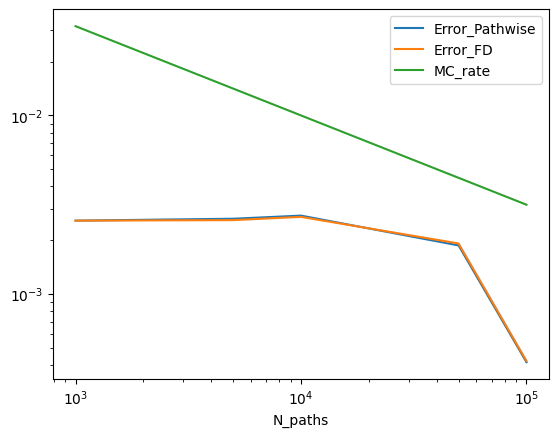

In [121]:
N_list = [1000, 5000, 10000, 50000, 100000]
results = []

rng = np.random.default_rng(123)

for N in N_list:
    #rng = np.random.default_rng()
    Z = rng.normal(0.0, 1.0, (N, NoOfSteps))
    
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    delta_pw = PathwiseDelta(CP, S0, paths["S"], K, r, T)

    #delta diferencias finitas
    paths_up = GeneratePathsGBM_givenZ(Z,T,r,sigma,S0+h)
    paths_dn = GeneratePathsGBM_givenZ(Z,T,r,sigma,S0-h)

    ST_up = paths_up["S"][:, -1]
    ST_dn = paths_dn["S"][:, -1]

    price_up = opcion_europea(CP, ST_up, K, r, T)
    price_dn = opcion_europea(CP, ST_dn, K, r, T)

    delta_fd=(price_up-price_dn)/(2*h)
    
    
    delta_bs = BS_delta(CP,S0,K,sigma,t,T,r)
    
    results.append([
        N,
        delta_pw,
        abs(delta_pw - delta_bs),
        delta_fd,
        abs(delta_fd - delta_bs),
        1/np.sqrt(N)
    ])

results = pd.DataFrame(results, columns=[
    "N_paths",
    "Delta_Pathwise",
    "Error_Pathwise",
    "Delta_FD",
    "Error_FD",
    "MC_rate"
])
results.plot(
    x="N_paths",
    y=["Error_Pathwise","Error_FD","MC_rate"],
    logx=True,
    logy=True
)
results

Con la gráfica de arriba podemos ver que el estimador Pathwise y el estimador de diferencias finitas centradas convergen hacia el delta analítico de Black-Scholes a medida que aumenta el número de trayectorias simuladas. La tasa de convergencia sigue el comportamiento teórico del método de Monte Carlo O(N^(-1/2)). Los dos estimadores tienen una precisión muy similar, debido a la suavidad del payoff de la opción call europea y al uso de CRN.

Ahora voy a ver la **varianza del estimador de MC**. Vamos a comparar ambas varianzas para ver cuál de ellos es más estable.

Voy a hacer varias repeticiones independientes. Para cada una de esas repeticiones calculo delta con PW y con DF.

In [122]:
def estimadores_delta(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h):
    Z = np.random.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))
    
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    S = paths["S"]
    delta_pw = PathwiseDelta(CP, S0, S, K, r, T)

    #diferencias finitas    
    paths_up = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0 + h)
    ST_up = paths_up["S"][:, -1]

    paths_dn = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0 - h)
    ST_dn = paths_dn["S"][:, -1]

    price_up = opcion_europea(CP, ST_up, K, r, T)
    price_dn = opcion_europea(CP, ST_dn, K, r, T)

    # FD centrada
    delta_fd = (price_up - price_dn) / (2*h)
    
    return delta_pw, delta_fd

,N_paths,Mean_Pathwise,Var_Pathwise,Std_Pathwise,Mean_FD_centered,Var_FD_centered,Std_FD_centered
0,1000,0.637028,0.000080,0.008933,0.637002,0.000080,0.008930
1,5000,0.636573,0.000017,0.004102,0.636569,0.000017,0.004086
2,10000,0.636373,0.000009,0.002961,0.636377,0.000009,0.002953
3,50000,0.636695,0.000001,0.001124,0.636693,0.000001,0.001125


<Axes: xlabel='N_paths'>

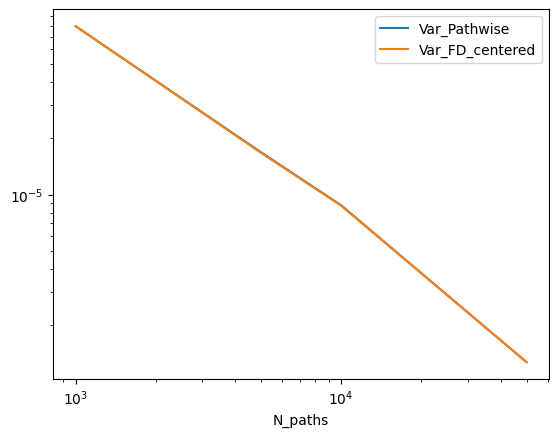

In [123]:
import pandas as pd

N_list = [1000, 5000, 10000, 50000]
M = 100

results = []

for N in N_list:
    pw_values = []
    fd_values = []

    for _ in range(M):
        delta_pw, delta_fd = estiamdores_delta(
            CP='call',
            S0=S0,
            K=K,
            r=r,
            T=T,
            sigma=sigma,
            NoOfPaths=N,
            NoOfSteps=NoOfSteps,
            h=h)

        pw_values.append(delta_pw)
        fd_values.append(delta_fd)

    pw_values = np.array(pw_values)
    fd_values = np.array(fd_values)

    results.append([
        N,
        np.mean(pw_values),
        np.var(pw_values, ddof=1),
        np.std(pw_values, ddof=1),
        np.mean(fd_values),
        np.var(fd_values, ddof=1),
        np.std(fd_values, ddof=1)
    ])

results = pd.DataFrame(results, columns=[
    "N_paths",
    "Mean_Pathwise",
    "Var_Pathwise",
    "Std_Pathwise",
    "Mean_FD_centered",
    "Var_FD_centered",
    "Std_FD_centered"
])

display(results)

results.plot(
    x="N_paths",
    y=["Var_Pathwise","Var_FD_centered"],
    logx=True,
    logy=True
)

Resultados muy similares en términos de media y varianza para una opción call europea bajo GBM

##### 2. Dependencia del tamaño de h

In [ ]:
Pathwise no deberia cambiar con cada h. Por lo tanto ueremos generar Z antes del bucle

In [124]:
import numpy as np
import pandas as pd

h_list = [2.0, 1.0, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]
N = 10000
M = 500

delta_bs = BS_delta(CP, S0, K, sigma, t, T, r)

results_h = []

# guardamos todos los valores por h
pw_all = []
fd_all_dict = {h: [] for h in h_list}

for _ in range(M):
    # una Z por repetición
    Z = np.random.normal(0.0, 1.0, (N, NoOfSteps))

    # Pathwise con esa Z
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    S = paths["S"]
    delta_pw = PathwiseDelta(CP, S0, S, K, r, T)
    pw_all.append(delta_pw)

    # FD centrada para todos los h usando la MISMA Z
    for h in h_list:
        paths_up = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0 + h)
        paths_dn = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0 - h)

        ST_up = paths_up["S"][:, -1]
        ST_dn = paths_dn["S"][:, -1]

        price_up = opcion_europea(CP, ST_up, K, r, T)
        price_dn = opcion_europea(CP, ST_dn, K, r, T)

        delta_fd = (price_up - price_dn) / (2 * h)
        
        #voy añadiendo para cada h la delta con DF
        fd_all_dict[h].append(delta_fd)

pw_all = np.array(pw_all)

#estadisticas para PW, son las mismas porque no cambia delta según h
mean_pw = np.mean(pw_all)
var_pw = np.var(pw_all, ddof=1)
bias_pw = mean_pw - delta_bs
abs_bias_pw = abs(bias_pw)
mse_pw = var_pw + bias_pw**2


for h in h_list:
    fd_values = np.array(fd_all_dict[h])

    mean_fd = np.mean(fd_values)
    var_fd = np.var(fd_values, ddof=1)
    bias_fd = mean_fd - delta_bs
    abs_bias_fd = abs(bias_fd)
    mse_fd = var_fd + bias_fd**2


    results_h.append([
        h,
        mean_pw,
        bias_pw,
        abs_bias_pw,
        var_pw,
        mse_pw,
        mean_fd,
        bias_fd,
        abs_bias_fd,
        var_fd,
        mse_fd
    ])

results_h = pd.DataFrame(results_h, columns=[
    "h",
    "Mean_Pathwise",
    "Bias_Pathwise",
    "AbsBias_Pathwise",
    "Var_Pathwise",
    "MSE_Pathwise",
    "Mean_FD_centered",
    "Bias_FD_centered",
    "AbsBias_FD_centered",
    "Var_FD_centered",
    "MSE_FD_centered"
])

display(results_h)



,h,Mean_Pathwise,Bias_Pathwise,AbsBias_Pathwise,Var_Pathwise,MSE_Pathwise,Mean_FD_centered,Bias_FD_centered,AbsBias_FD_centered,Var_FD_centered,MSE_FD_centered
0,2.000,0.636843,0.000012,0.000012,0.000008,0.000008,0.636447,-0.000383,0.000383,0.000007,0.000007
1,1.000,0.636843,0.000012,0.000012,0.000008,0.000008,0.636726,-0.000105,0.000105,0.000008,0.000008
2,0.500,0.636843,0.000012,0.000012,0.000008,0.000008,0.636807,-0.000024,0.000024,0.000008,0.000008
3,0.100,0.636843,0.000012,0.000012,0.000008,0.000008,0.636833,0.000002,0.000002,0.000008,0.000008
4,0.050,0.636843,0.000012,0.000012,0.000008,0.000008,0.636835,0.000004,0.000004,0.000008,0.000008
5,0.010,0.636843,0.000012,0.000012,0.000008,0.000008,0.636837,0.000007,0.000007,0.000008,0.000008
6,0.005,0.636843,0.000012,0.000012,0.000008,0.000008,0.636839,0.000008,0.000008,0.000008,0.000008
7,0.001,0.636843,0.000012,0.000012,0.000008,0.000008,0.636842,0.000011,0.000011,0.000008,0.000008


<Axes: xlabel='h'>

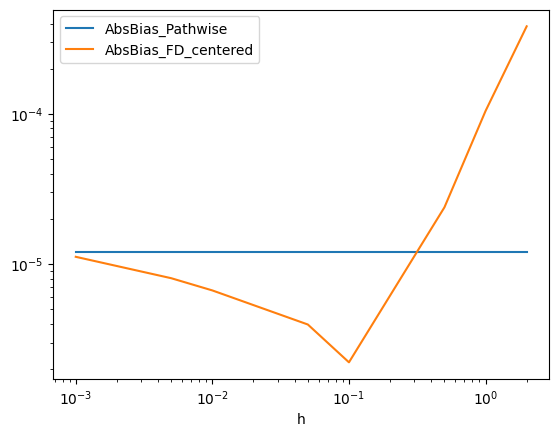

In [125]:
results_h.plot(
    x="h",
    y=["AbsBias_Pathwise", "AbsBias_FD_centered"],
    logx=True,
    logy=True
)

<Axes: xlabel='h'>

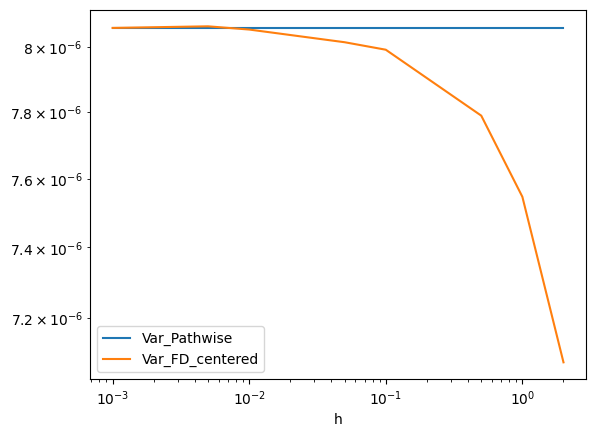

In [126]:
results_h.plot(
    x="h",
    y=["Var_Pathwise", "Var_FD_centered"],
    logx=True,
    logy=True
)

La varianza del estimador Pathwise es constante al variar el parámetro porque este método no utiliza perturbaciones del precio inicial. En cambio, el estimador de diferencias finitas centradas muestra una ligera dependencia respecto a h. Para valores muy pequeños de h el ruido estadístico del método de Monte Carlo puede amplificarse, aumentando la varianza del estimador.

<Axes: xlabel='h'>

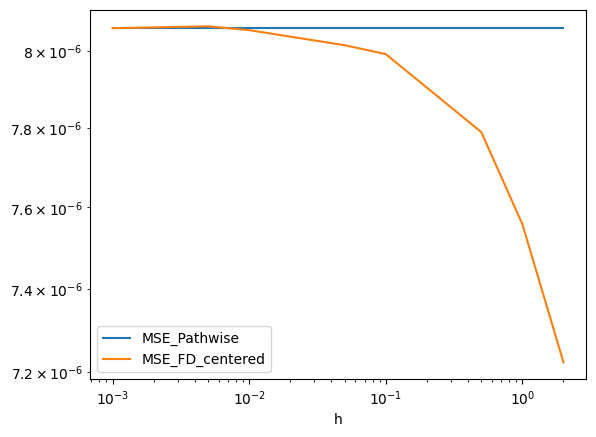

In [127]:
results_h.plot(
    x="h",
    y=["MSE_Pathwise", "MSE_FD_centered"],
    logx=True,
    logy=True
)